# APM1220 – PCA of Cross-Country Well-Being (World Happiness Report 2021)
PCA on the **correlation matrix** of the standardized variables. All numerical results are reported to three decimal places.

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.decomposition import PCA

pd.options.display.float_format = '{:.3f}'.format
pd.options.display.width = 200
sns.set_theme(style='whitegrid')

df = pd.read_csv('world-happiness-report-2021.csv')
cols = ['Ladder score', 'Logged GDP per capita', 'Social support', 'Healthy life expectancy',
        'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']
X = df[cols]    # Country name and Regional indicator are excluded

# Part A – Data Preparation and Descriptive Analysis

### A1. Observations and variables

In [2]:
print(f'Observations (countries): {X.shape[0]}')
print(f'Variables: {X.shape[1]}')
for i, v in enumerate(cols, 1): print(f'  {i}. {v}')
print('Missing values:', int(X.isna().sum().sum()))

Observations (countries): 149
Variables: 7
  1. Ladder score
  2. Logged GDP per capita
  3. Social support
  4. Healthy life expectancy
  5. Freedom to make life choices
  6. Generosity
  7. Perceptions of corruption
Missing values: 0


**Answer:** **n = 149 countries** and **p = 7 quantitative variables** (listed above); there are no missing values.

### A2. Mean and standard deviation

In [3]:
desc = pd.DataFrame({'Mean': X.mean(), 'Std. deviation': X.std(ddof=1)})
desc

,Mean,Std. deviation
Ladder score,5.533,1.074
Logged GDP per capita,9.432,1.159
Social support,0.815,0.115
Healthy life expectancy,64.993,6.762
Freedom to make life choices,0.792,0.113
Generosity,-0.015,0.151
Perceptions of corruption,0.727,0.179


**Answer:** see the table (sample SD, n − 1). The means and SDs differ greatly in magnitude, e.g. life expectancy (mean 64.993, SD 6.762) versus social support (mean 0.815, SD 0.115).

### A3. Why standardize?

**Answer:** The variables are measured on very different scales and units (years, log-dollars, 0–1 proportions, index scores). PCA finds directions of maximum variance, so unstandardized variables with large variances (life expectancy, SD 6.762) would dominate the first component regardless of their importance. Standardizing (mean 0, SD 1) gives each variable equal weight, and the covariance matrix of the standardized data is the **correlation matrix**, which is the basis of this PCA.

In [4]:
Z = (X - X.mean()) / X.std(ddof=1)         # z-scores
print('Means of Z (≈0):', Z.mean().round(3).values)
print('SDs of Z   (=1):', Z.std(ddof=1).round(3).values)

Means of Z (≈0): [-0. -0.  0.  0. -0.  0. -0.]
SDs of Z   (=1): [1. 1. 1. 1. 1. 1. 1.]


### A4. Correlation matrix

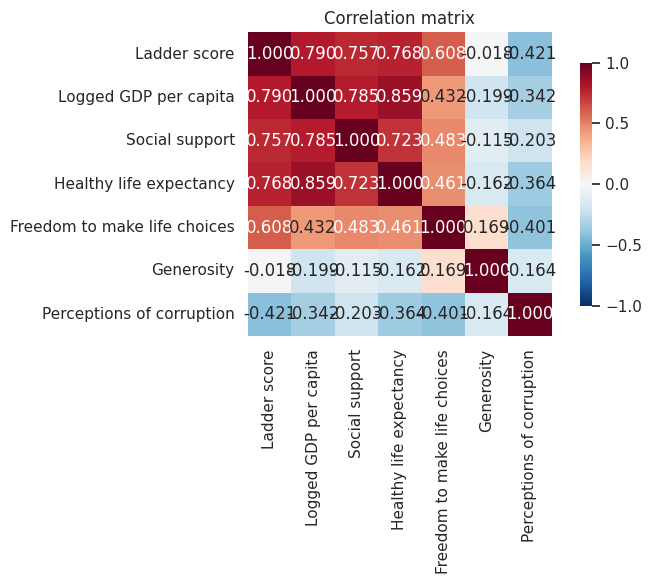

,Ladder score,Logged GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
Ladder score,1.000,0.790,0.757,0.768,0.608,-0.018,-0.421
Logged GDP per capita,0.790,1.000,0.785,0.859,0.432,-0.199,-0.342
Social support,0.757,0.785,1.000,0.723,0.483,-0.115,-0.203
Healthy life expectancy,0.768,0.859,0.723,1.000,0.461,-0.162,-0.364
Freedom to make life choices,0.608,0.432,0.483,0.461,1.000,0.169,-0.401
Generosity,-0.018,-0.199,-0.115,-0.162,0.169,1.000,-0.164
Perceptions of corruption,-0.421,-0.342,-0.203,-0.364,-0.401,-0.164,1.000


In [5]:
R = X.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(R, annot=True, fmt='.3f', cmap='RdBu_r', vmin=-1, vmax=1, square=True, cbar_kws={'shrink': .8})
plt.title('Correlation matrix'); plt.tight_layout(); plt.show()
R

In [6]:
pairs = (R.where(np.triu(np.ones(R.shape, dtype=bool), 1)).stack()
           .rename('r').reset_index().rename(columns={'level_0': 'Variable 1', 'level_1': 'Variable 2'}))
pairs = pairs.reindex(pairs['r'].abs().sort_values(ascending=False).index)
pairs.head(8)

,Variable 1,Variable 2,r
10,Logged GDP per capita,Healthy life expectancy,0.859
1,Ladder score,Logged GDP per capita,0.790
9,Logged GDP per capita,Social support,0.785
3,Ladder score,Healthy life expectancy,0.768
2,Ladder score,Social support,0.757
17,Social support,Healthy life expectancy,0.723
4,Ladder score,Freedom to make life choices,0.608
18,Social support,Freedom to make life choices,0.483


**Description:** Ladder score, GDP, social support and healthy life expectancy form a tightly inter-correlated block; freedom is moderately related to them; perceived corruption is negatively related to the rest; generosity is weakly related to everything (|r| ≤ 0.199).

**Strong relationships:**
- **Positive:** Logged GDP per capita and Healthy life expectancy (r = **0.859**); Ladder score and Logged GDP per capita (r = **0.790**); also GDP and social support (0.785), and Ladder score and life expectancy (0.768).
- **Negative:** Ladder score and Perceptions of corruption (r = **−0.421**) and Freedom and Perceptions of corruption (r = **−0.401**). These are the strongest negative relationships, though only moderate.

# Part B – Principal Component Analysis

### B1. PCA using the correlation matrix

In [7]:
# Eigen-decomposition of the correlation matrix R
vals, vecs = np.linalg.eigh(R.values)
order = np.argsort(vals)[::-1]
vals, vecs = vals[order], vecs[:, order]
vecs = vecs * np.where(vecs[0] < 0, -1, 1)        # sign convention: Ladder score coefficient positive
pcs = [f'PC{i+1}' for i in range(7)]

# Cross-check with scikit-learn PCA on the z-scores
chk = PCA().fit(Z)
print('Matches scikit-learn PCA on standardized data:', np.allclose(chk.explained_variance_, vals))
print('Sum of eigenvalues =', round(vals.sum(), 3), '(= number of variables)')

Matches scikit-learn PCA on standardized data: True
Sum of eigenvalues = 7.0 (= number of variables)


**Answer:** PCA was carried out by the eigen-decomposition of the 7 × 7 correlation matrix of the standardized variables (verified against `sklearn.decomposition.PCA`).

### B2–B4. Eigenvalues, proportion of variance, cumulative proportion

In [8]:
eig = pd.DataFrame({'Eigenvalue': vals,
                    'Proportion of variance': vals / vals.sum(),
                    'Cumulative proportion': (vals / vals.sum()).cumsum()}, index=pcs)
eig

,Eigenvalue,Proportion of variance,Cumulative proportion
PC1,3.914,0.559,0.559
PC2,1.289,0.184,0.743
PC3,0.708,0.101,0.844
PC4,0.518,0.074,0.918
PC5,0.251,0.036,0.954
PC6,0.193,0.028,0.982
PC7,0.126,0.018,1.000


**B2. Eigenvalues:** 3.914, 1.289, 0.708, 0.518, 0.251, 0.193, 0.126 (PC1–PC7).

**B3. Proportion of variance** (λᵢ / Σλ = λᵢ / 7): 0.559, 0.184, 0.101, 0.074, 0.036, 0.028, 0.018.

**B4. Cumulative proportion:** 0.559, 0.743, 0.844, 0.918, 0.954, 0.982, 1.000.

### B5. Eigenvectors (component coefficients) of the retained components (PC1, PC2)

In [9]:
load_vec = pd.DataFrame(vecs, index=cols, columns=pcs)
load_vec[['PC1', 'PC2']]

,PC1,PC2
Ladder score,0.464,0.040
Logged GDP per capita,0.459,-0.197
Social support,0.433,-0.163
Healthy life expectancy,0.453,-0.146
Freedom to make life choices,0.341,0.365
Generosity,-0.042,0.753
Perceptions of corruption,-0.252,-0.460


**Answer:** the table above gives the coefficients of PC1 and PC2 (the two retained components, justified in Part C).

### B6. Largest absolute coefficients in PC1

In [10]:
load_vec['PC1'].abs().sort_values(ascending=False).to_frame('|PC1 coefficient|').join(load_vec['PC1'].rename('PC1 coefficient'))

,|PC1 coefficient|,PC1 coefficient
Ladder score,0.464,0.464
Logged GDP per capita,0.459,0.459
Healthy life expectancy,0.453,0.453
Social support,0.433,0.433
Freedom to make life choices,0.341,0.341
Perceptions of corruption,0.252,-0.252
Generosity,0.042,-0.042


**Answer:** The largest absolute coefficients in PC1 are **Ladder score (0.464)**, **Logged GDP per capita (0.459)**, **Healthy life expectancy (0.453)** and **Social support (0.433)**, followed by Freedom (0.341) and Perceptions of corruption (−0.252). Generosity (−0.042) is nearly zero.

# Part C – Determining the Number of Components

### C1–C2. Scree plot and elbow

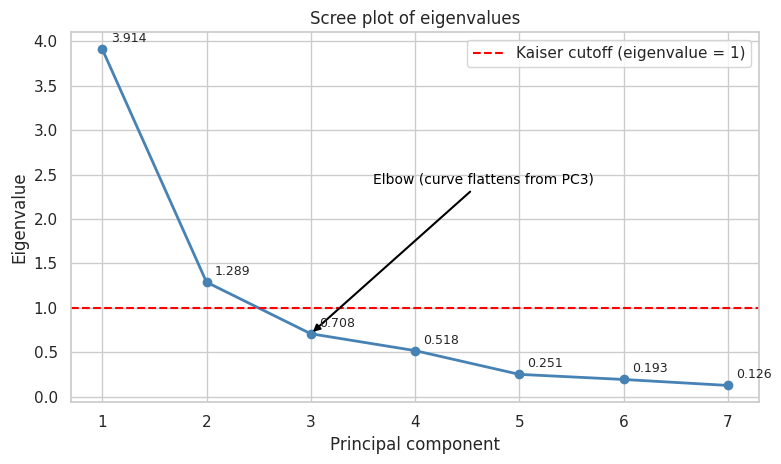

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(range(1, 8), vals, 'o-', lw=2, color='steelblue')
ax.axhline(1, color='red', ls='--', label='Kaiser cutoff (eigenvalue = 1)')
ax.annotate('Elbow (curve flattens from PC3)', xy=(3, vals[2]), xytext=(3.6, 2.4),
            arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5), fontsize=10, color='black')
for i, v in enumerate(vals, 1): ax.text(i + 0.08, v + 0.08, f'{v:.3f}', fontsize=9)
ax.set(title='Scree plot of eigenvalues', xlabel='Principal component', ylabel='Eigenvalue', xticks=range(1, 8))
ax.legend(); plt.tight_layout(); plt.show()

**C1:** Scree plot shown above.

**C2: Elbow:** The curve falls steeply from PC1 (3.914) to PC2 (1.289) and then flattens. The **elbow is at PC3** (eigenvalue 0.708); components before the elbow (**PC1 and PC2**) are retained.

### C3. Kaiser criterion

In [12]:
kaiser = eig[eig['Eigenvalue'] > 1]
print('Components with eigenvalue > 1:', list(kaiser.index))
kaiser[['Eigenvalue']]

Components with eigenvalue > 1: ['PC1', 'PC2']


,Eigenvalue
PC1,3.914
PC2,1.289


**Answer:** Only **PC1 (3.914)** and **PC2 (1.289)** have eigenvalues greater than 1. Therefore, the Kaiser criterion suggests **2 components**.

### C4. Number of components to retain

**Answer:** Retain **2 principal components**.
- Scree plot: elbow at PC3, so two components before it.
- Kaiser: two eigenvalues are greater than 1 (3.914, 1.289).
- Cumulative variance: PC1 + PC2 = **74.3%**. PC3 adds only 10.1% (eigenvalue 0.708 < 1) and is dominated by a single variable (corruption).
- Interpretability: PC1 and PC2 each have a clear meaning (Part D).

### C5. Why not rely on one criterion?

**Answer:** No single rule is definitive. The scree elbow is subjective, the Kaiser rule can retain too many or too few components, and a variance threshold (e.g. 70–80%) is arbitrary. The decision should combine the scree plot, eigenvalue magnitudes, cumulative variance explained and subject-matter interpretability, and the criteria should agree, as they do here.

# Part D – Interpretation of Principal Components

Coefficients and loadings (variable–PC correlations), retained components:


,PC1 coef.,PC2 coef.,PC1 loading,PC2 loading,Communality (PC1+PC2)
Ladder score,0.464,0.040,0.918,0.045,0.845
Logged GDP per capita,0.459,-0.197,0.908,-0.223,0.875
Social support,0.433,-0.163,0.856,-0.185,0.766
Healthy life expectancy,0.453,-0.146,0.896,-0.166,0.831
Freedom to make life choices,0.341,0.365,0.674,0.414,0.626
Generosity,-0.042,0.753,-0.084,0.855,0.739
Perceptions of corruption,-0.252,-0.460,-0.499,-0.522,0.522


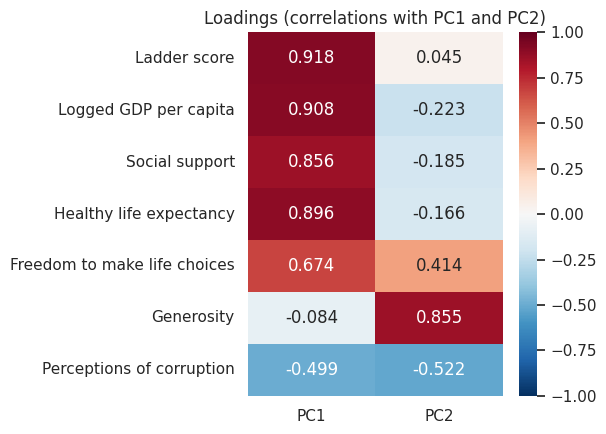

In [13]:
load_cor = load_vec * np.sqrt(vals)                 # correlation between each variable and each PC
comm = (load_cor[['PC1', 'PC2']] ** 2).sum(axis=1).rename('Communality (PC1+PC2)')
print('Coefficients and loadings (variable–PC correlations), retained components:')
display(pd.concat([load_vec[['PC1', 'PC2']].add_suffix(' coef.'), load_cor[['PC1', 'PC2']].add_suffix(' loading'), comm], axis=1))

plt.figure(figsize=(6, 4.5))
sns.heatmap(load_cor[['PC1', 'PC2']], annot=True, fmt='.3f', cmap='RdBu_r', vmin=-1, vmax=1)
plt.title('Loadings (correlations with PC1 and PC2)'); plt.tight_layout(); plt.show()

### D1. Interpretation of PC1

**Answer:** PC1 (55.9% of variance) has large **positive** coefficients on Ladder score (0.464), GDP (0.459), life expectancy (0.453) and social support (0.433), a moderate positive coefficient on freedom (0.341), and a **negative** coefficient on perceptions of corruption (−0.252). Generosity is negligible (−0.042). A high PC1 score marks a country that is wealthy, healthy, socially supported, relatively free, with lower perceived corruption and higher life evaluations. A low score marks the opposite.

### D2. Interpretation of PC2

**Answer:** PC2 (18.4%) is dominated by **Generosity (0.753)**, with **Freedom (0.365)** also positive, against **Perceptions of corruption (−0.460)**. GDP (−0.197), social support (−0.163) and life expectancy (−0.146) have small negative coefficients, and Ladder score is about zero (0.040). A high PC2 score marks a country that is more generous and freer, with lower perceived corruption, than its income level would suggest. A low score marks the opposite (e.g. Greece, Lebanon, Hungary, Venezuela, Turkey).

### D3. Name for PC1

**Answer:** **"Overall Socioeconomic Well-Being (Prosperity, Health and Social Support) Index."** The four variables with the largest and nearly equal coefficients (Ladder score, GDP, life expectancy, social support) all measure material and social conditions of life, and the negative corruption coefficient fits with institutional quality. PC1 correlates 0.918 with the Ladder score itself.

### D4. How many original variables can the retained components represent?

**Answer:** The **two retained components can represent all seven original variables** (7 → 2 dimensions, retaining 74.3% of total variance). The communalities in the table show how well:
- Well represented (communality > 0.70): Logged GDP (0.875), Ladder score (0.845), life expectancy (0.831), social support (0.766) and generosity (0.739), **five variables**.
- Only moderately represented: freedom (0.626) and corruption (0.522), which are partly carried by PC3.
- PC1 alone summarizes the four-variable block of Ladder score, GDP, life expectancy and social support (loadings ≥ 0.856), and PC2 mainly covers generosity.

### Supporting figure: biplot

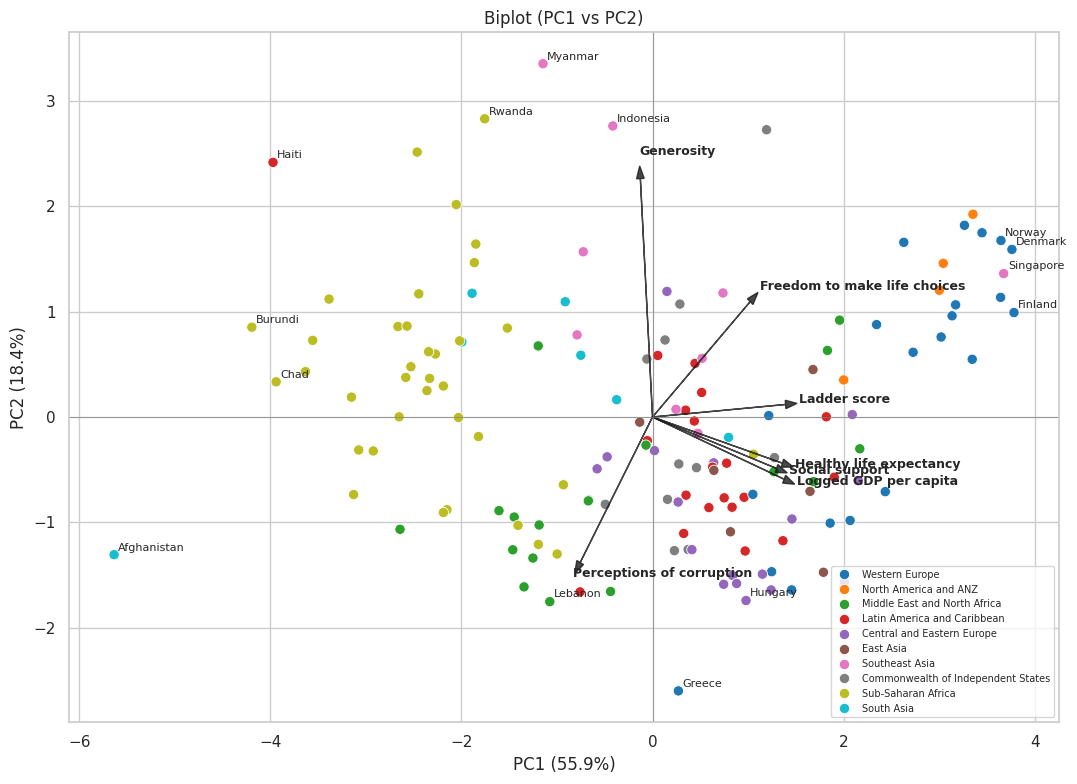

Highest PC1: ['Finland', 'Denmark', 'Singapore', 'Norway', 'Switzerland']
Lowest PC1:  ['Afghanistan', 'Burundi', 'Haiti', 'Chad', 'Togo']


In [14]:
scores = pd.DataFrame((Z.values @ vecs)[:, :2], columns=['PC1', 'PC2'])
scores.insert(0, 'Country', df['Country name']); scores['Region'] = df['Regional indicator']

fig, ax = plt.subplots(figsize=(11, 8))
sns.scatterplot(data=scores, x='PC1', y='PC2', hue='Region', s=55, ax=ax, palette='tab10')
extreme = pd.concat([scores.nlargest(4, 'PC1'), scores.nsmallest(4, 'PC1'),
                     scores.nlargest(3, 'PC2'), scores.nsmallest(3, 'PC2')]).drop_duplicates('Country')
for _, r in extreme.iterrows():
    ax.annotate(r['Country'], (r['PC1'], r['PC2']), fontsize=8, xytext=(3, 3), textcoords='offset points')
k = 3.0
for v in cols:
    ax.arrow(0, 0, load_vec.loc[v, 'PC1'] * k, load_vec.loc[v, 'PC2'] * k, color='k', head_width=.08, alpha=.8)
    ax.text(load_vec.loc[v, 'PC1'] * k * 1.1, load_vec.loc[v, 'PC2'] * k * 1.1, v, fontsize=9, weight='bold')
ax.axhline(0, color='gray', lw=.5); ax.axvline(0, color='gray', lw=.5)
ax.set(title='Biplot (PC1 vs PC2)', xlabel=f'PC1 ({eig.iloc[0,1]:.1%})', ylabel=f'PC2 ({eig.iloc[1,1]:.1%})')
ax.legend(fontsize=7, loc='lower right'); plt.tight_layout(); plt.show()
print('Highest PC1:', list(scores.nlargest(5, 'PC1')['Country']))
print('Lowest PC1: ', list(scores.nsmallest(5, 'PC1')['Country']))

### D5. Conclusion

**Answer:** PCA shows that cross-country well-being in this dataset is essentially **two-dimensional**. Seven correlated indicators are summarized by two uncorrelated components retaining **74.3%** of the variance.
1. **PC1 (55.9%)** is a general *prosperity–health–social support* dimension, on which life evaluations, income, longevity and social support rise together and corruption perceptions fall. It separates countries like Finland, Denmark and Singapore from Afghanistan, Burundi and Haiti.
2. **PC2 (18.4%)** is a *generosity/freedom versus perceived corruption* dimension that is largely independent of income, showing that national well-being is not determined by wealth alone.

*Caveats:* the Ladder score is an outcome of the other indicators, which strengthens PC1; freedom and corruption are only moderately captured by two components; the signs of components are arbitrary.